# Multi-Voice Activity Detection — Single File Analysis

This notebook runs both the **Traditional (signal-processing)** and **DNN** MVAD models on a single WAV file and displays prediction waveforms for comparison.

In [1]:
import sys
import numpy as np
import soundfile as sf

# Import everything from mvad_test.py
# (mvad_test.py forces matplotlib backend to 'Agg' at import time,
#  so we must re-set it to 'inline' AFTER the import)
from mvad_test import (
    MultivoiceVAD,
    load_dnn_model,
    dnn_predict_file,
)

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline
import matplotlib.pyplot as plt

print('Imports OK, matplotlib backend:', matplotlib.get_backend())

Imports OK, matplotlib backend: module://matplotlib_inline.backend_inline


## 1. Configuration

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────
INPUT_WAV   = 'inputs/example_10.wav'
DNN_MODEL   = 'mvad_dnn_model_ep47.pt'

# ── Traditional VAD parameters (defaults from mvad_test.py) ───────────────
FRAME_MS              = 30
HOP_MS                = 10
ENERGY_THRESHOLD_DB   = -40
PITCH_CONF_THRESH     = 0.25
YIN_THRESHOLD         = 0.15
SECONDARY_PITCH_CONF  = 0.20
SF_THRESHOLD          = 0.30
OVERLAP_THRESHOLD     = 0.38
CONTEXT_FRAMES        = 3
MEDIAN_FILTER         = 7
F0_MIN                = 80
F0_MAX                = 400

## 2. Load audio

In [3]:
signal, sr = sf.read(INPUT_WAV, dtype='float64')
if signal.ndim > 1:
    signal = np.mean(signal, axis=1)

duration = len(signal) / sr
print(f'File     : {INPUT_WAV}')
print(f'SR       : {sr} Hz')
print(f'Duration : {duration:.2f} s')
print(f'Samples  : {len(signal):,}')

File     : inputs/example_10.wav
SR       : 48000 Hz
Duration : 61.44 s
Samples  : 2,949,120


## 3. Run Traditional VAD

In [4]:
vad = MultivoiceVAD(
    sr=sr,
    frame_ms=FRAME_MS,
    hop_ms=HOP_MS,
    energy_threshold_db=ENERGY_THRESHOLD_DB,
    pitch_conf_thresh=PITCH_CONF_THRESH,
    yin_threshold=YIN_THRESHOLD,
    secondary_pitch_conf=SECONDARY_PITCH_CONF,
    spectral_flatness_overlap=SF_THRESHOLD,
    overlap_threshold=OVERLAP_THRESHOLD,
    context_frames=CONTEXT_FRAMES,
    median_filter_size=MEDIAN_FILTER,
    f0_min=F0_MIN,
    f0_max=F0_MAX,
)

trad_labels, trad_features = vad.process(signal)

n_trad = len(trad_labels)
hop_s = vad.hop_len / sr
trad_times = np.arange(n_trad) * hop_s

print(f'Traditional VAD: {n_trad} frames')
for lab, name in [(0, 'Silence'), (1, 'Single'), (2, 'Overlap')]:
    cnt = np.sum(trad_labels == lab)
    print(f'  {name:20s}: {cnt:6d} frames  ({cnt/n_trad*100:5.1f}%)  {cnt*hop_s:.2f}s')

  Analysing 6142 frames  (frame=30 ms, hop=10 ms) …
Traditional VAD: 6142 frames
  Silence             :   2304 frames  ( 37.5%)  23.04s
  Single              :   2671 frames  ( 43.5%)  26.71s
  Overlap             :   1167 frames  ( 19.0%)  11.67s


## 4. Run DNN Model

In [5]:
model, cfg, feat_mean, feat_std, device = load_dnn_model(DNN_MODEL)

dnn_labels = dnn_predict_file(
    signal, sr, model, cfg, feat_mean, feat_std, device
)

n_dnn = len(dnn_labels)
dnn_hop_samples = cfg.get('hop_samples', int(sr * 0.01))
dnn_hop_s = dnn_hop_samples / sr
dnn_times = np.arange(n_dnn) * dnn_hop_s

print(f'DNN model: {n_dnn} frames (arch={cfg["arch"]})')
for lab, name in [(0, 'Silence'), (1, 'Single'), (2, 'Overlap')]:
    cnt = np.sum(dnn_labels == lab)
    print(f'  {name:20s}: {cnt:6d} frames  ({cnt/n_dnn*100:5.1f}%)  {cnt*dnn_hop_s:.2f}s')

  DNN model loaded: arch=cnn, context=15 frames (150 ms), n_mels=40, device=cuda
  Best epoch: 47
DNN model: 6145 frames (arch=cnn)
  Silence             :   1857 frames  ( 30.2%)  18.57s
  Single              :   2137 frames  ( 34.8%)  21.37s
  Overlap             :   2151 frames  ( 35.0%)  21.51s


## 5. Prediction Plots — Waveform + Coloured Timeline

Four panels:
1. **Audio waveform**
2. **Traditional VAD** — coloured timeline (grey=silence, green=single, red=overlap)
3. **DNN model** — coloured timeline
4. **Agreement** between both models (green=agree, red=disagree)

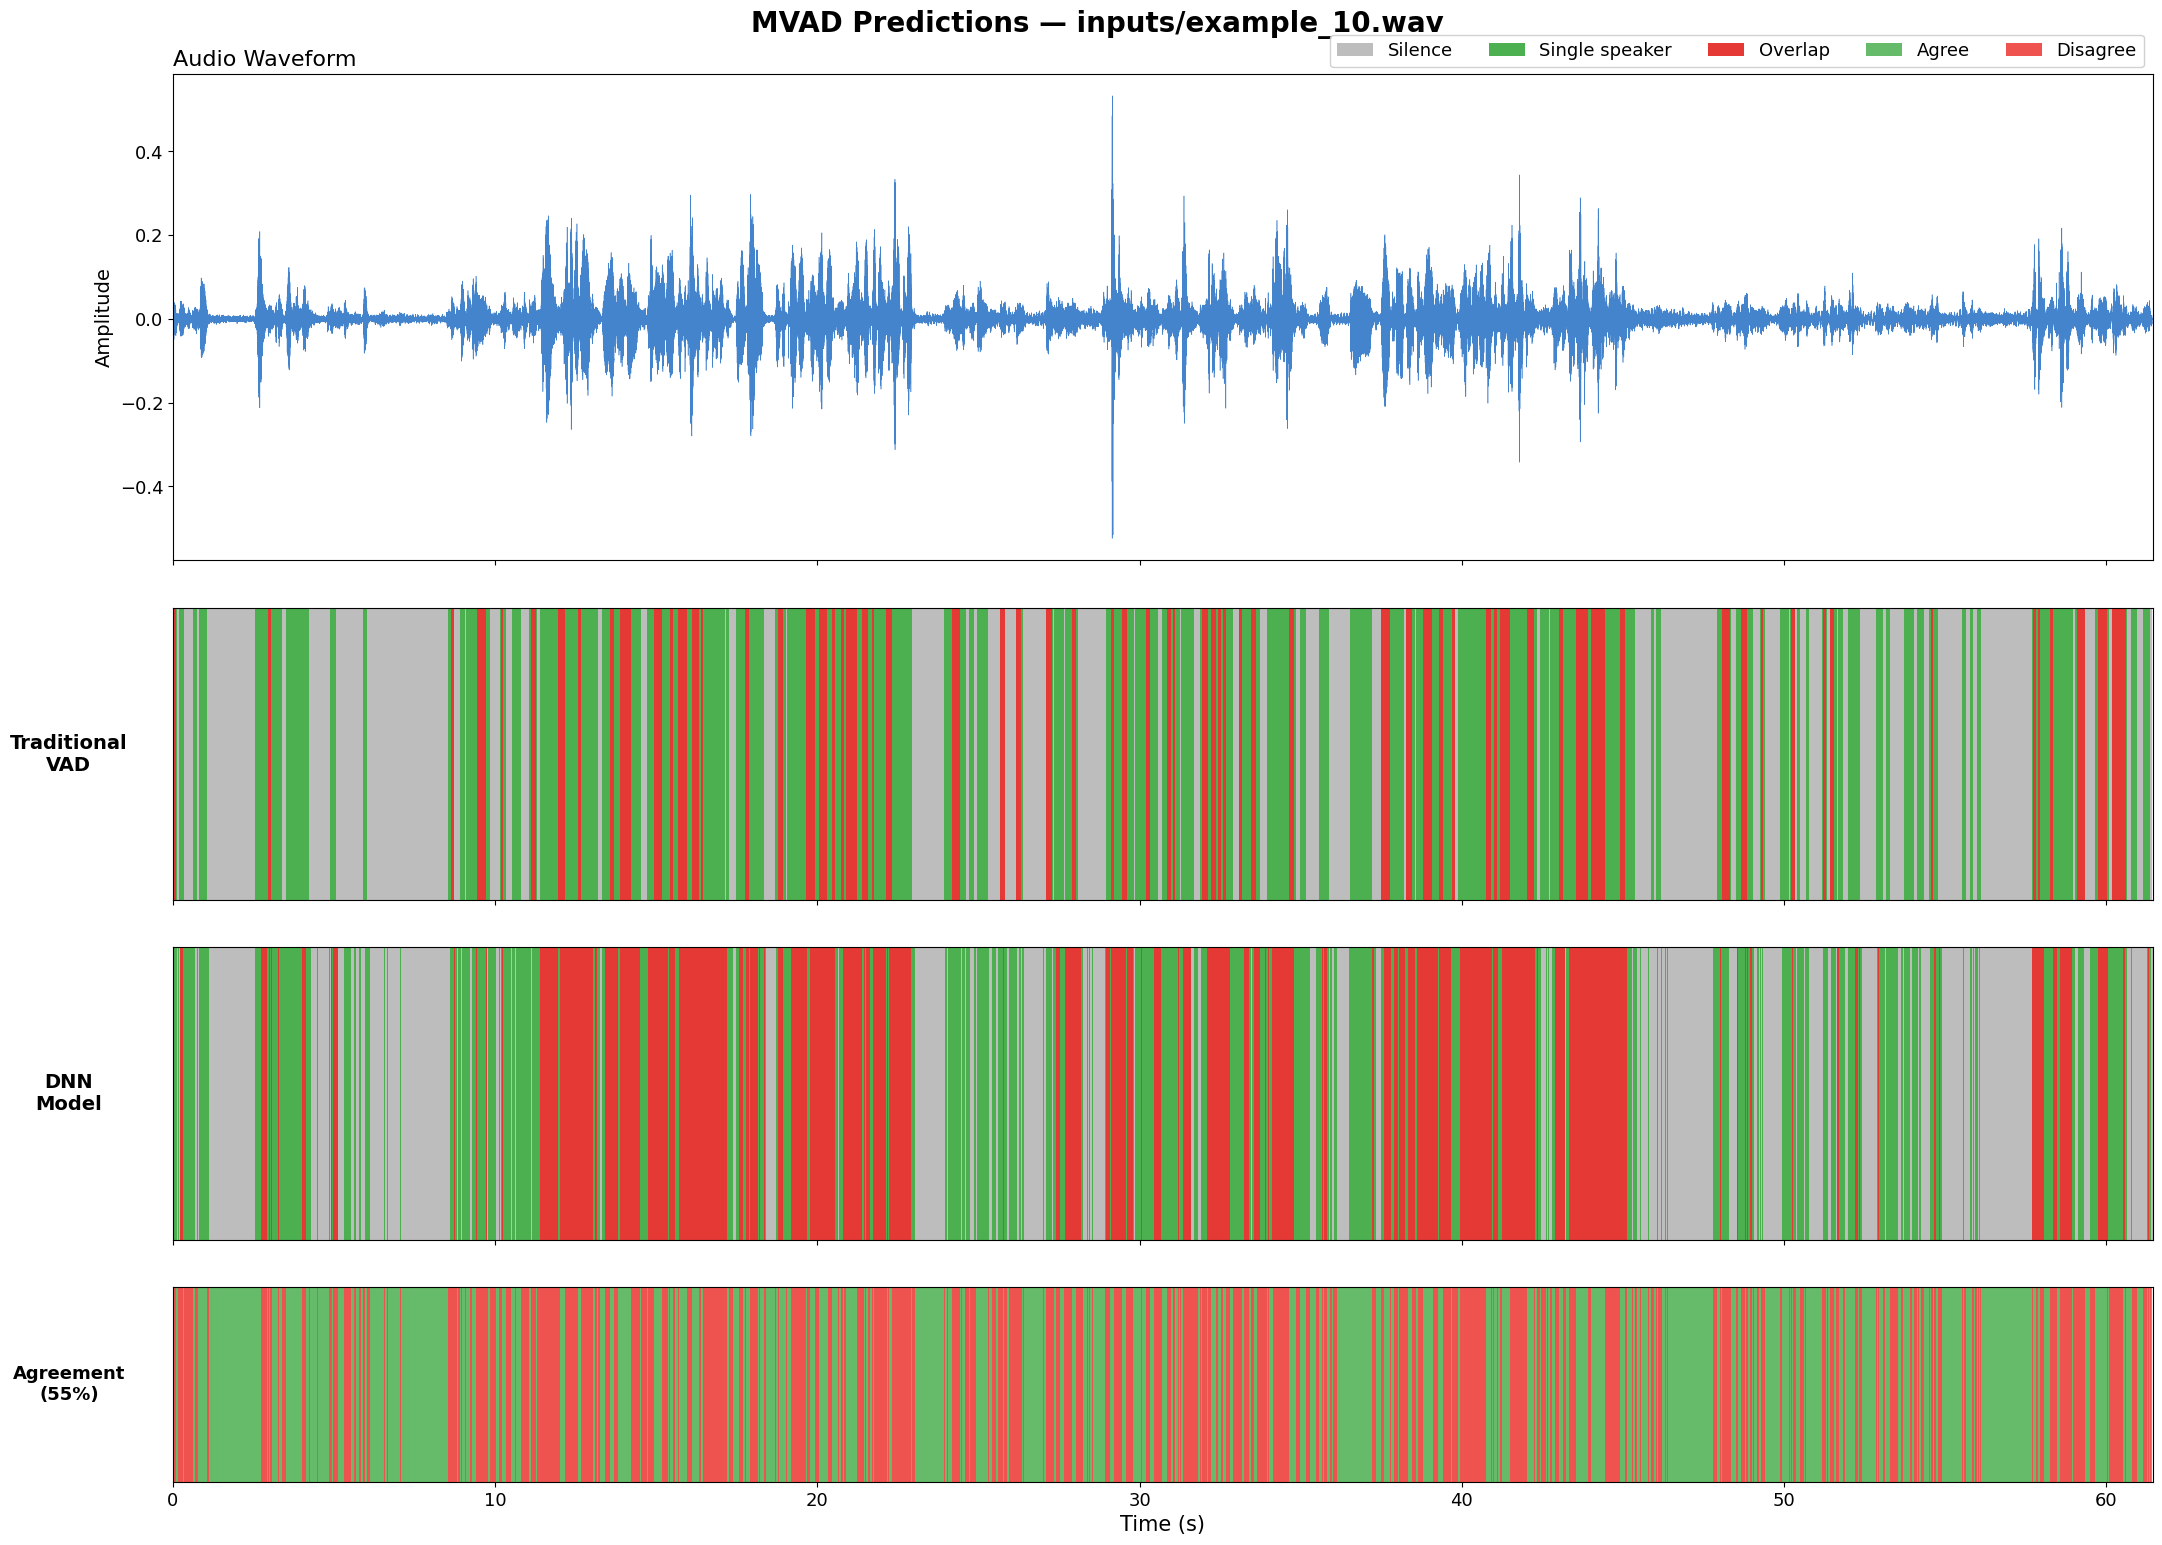

In [6]:
from matplotlib.patches import Patch
from matplotlib.collections import BrokenBarHCollection

CLASS_COLORS = {0: '#bdbdbd', 1: '#4caf50', 2: '#e53935'}
CLASS_NAMES  = {0: 'Silence', 1: 'Single speaker', 2: 'Overlap'}


def _label_segments(labels, hop_sec):
    """Convert frame labels to list of (start_sec, duration_sec, label)."""
    segments = []
    if len(labels) == 0:
        return segments
    cur_label = labels[0]
    seg_start = 0.0
    for i in range(1, len(labels)):
        if labels[i] != cur_label:
            segments.append((seg_start, i * hop_sec - seg_start, cur_label))
            cur_label = labels[i]
            seg_start = i * hop_sec
    segments.append((seg_start, len(labels) * hop_sec - seg_start, cur_label))
    return segments


def _draw_timeline(ax, segments, y_bottom=0, height=1):
    """Draw coloured horizontal bars for each segment on *ax*."""
    for start, dur, lab in segments:
        ax.barh(y_bottom + height / 2, dur, height=height, left=start,
                color=CLASS_COLORS[lab], edgecolor='none', linewidth=0)


# ── Build segments ────────────────────────────────────────────────────────
trad_segs = _label_segments(trad_labels, hop_s)
dnn_segs  = _label_segments(dnn_labels,  dnn_hop_s)

# ── Agreement array (resampled to common time base) ──────────────────────
common_hop = min(hop_s, dnn_hop_s)
common_end = min(trad_times[-1] if n_trad > 0 else 0,
                 dnn_times[-1]  if n_dnn  > 0 else 0)
common_t = np.arange(0, common_end, common_hop)
n_common = len(common_t)

trad_rs = np.array([trad_labels[min(int(t / hop_s),     n_trad - 1)] for t in common_t])
dnn_rs  = np.array([dnn_labels [min(int(t / dnn_hop_s), n_dnn  - 1)] for t in common_t])
agree_labels = (trad_rs == dnn_rs).astype(np.int32)   # 1=agree, 0=disagree
agree_segs = _label_segments(agree_labels, common_hop)

AGREE_COLORS = {0: '#ef5350', 1: '#66bb6a'}

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(22, 16), sharex=True,
                         gridspec_kw={'height_ratios': [2.5, 1.5, 1.5, 1],
                                      'hspace': 0.15})
fig.suptitle(f'MVAD Predictions — {INPUT_WAV}', fontsize=20, fontweight='bold', y=0.97)

# ── Panel 1: Waveform ────────────────────────────────────────────────────
t_sig = np.arange(len(signal)) / sr
axes[0].plot(t_sig, signal, lw=0.4, color='#1565c0', alpha=0.8)
axes[0].set_ylabel('Amplitude', fontsize=14)
axes[0].set_title('Audio Waveform', fontsize=16, loc='left')
axes[0].tick_params(axis='both', labelsize=13)
axes[0].margins(x=0)

# ── Panel 2: Traditional VAD ─────────────────────────────────────────────
_draw_timeline(axes[1], trad_segs)
axes[1].set_ylim(0, 1)
axes[1].set_yticks([])
axes[1].set_ylabel('Traditional\nVAD', fontsize=14, fontweight='bold',
                   rotation=0, labelpad=75, va='center')
axes[1].tick_params(axis='x', labelsize=13)
axes[1].margins(x=0)

# ── Panel 3: DNN ─────────────────────────────────────────────────────────
_draw_timeline(axes[2], dnn_segs)
axes[2].set_ylim(0, 1)
axes[2].set_yticks([])
axes[2].set_ylabel('DNN\nModel', fontsize=14, fontweight='bold',
                   rotation=0, labelpad=75, va='center')
axes[2].tick_params(axis='x', labelsize=13)
axes[2].margins(x=0)

# ── Panel 4: Agreement ──────────────────────────────────────────────────
for start, dur, lab in agree_segs:
    axes[3].barh(0.5, dur, height=1, left=start,
                 color=AGREE_COLORS[lab], edgecolor='none')
axes[3].set_ylim(0, 1)
axes[3].set_yticks([])
agree_pct = np.sum(agree_labels) / n_common * 100 if n_common > 0 else 0
axes[3].set_ylabel(f'Agreement\n({agree_pct:.0f}%)', fontsize=13, fontweight='bold',
                   rotation=0, labelpad=75, va='center')
axes[3].set_xlabel('Time (s)', fontsize=15)
axes[3].tick_params(axis='x', labelsize=13)
axes[3].margins(x=0)

# ── Shared legend ─────────────────────────────────────────────────────────
legend_patches = [Patch(fc=CLASS_COLORS[k], ec='none', label=CLASS_NAMES[k]) for k in [0, 1, 2]]
legend_patches += [Patch(fc='#66bb6a', ec='none', label='Agree'),
                   Patch(fc='#ef5350', ec='none', label='Disagree')]
fig.legend(handles=legend_patches, loc='upper right', ncol=5, fontsize=13,
           framealpha=0.9, bbox_to_anchor=(0.98, 0.96))

fig.subplots_adjust(left=0.08, right=0.98, top=0.93, bottom=0.05)
plt.show()

## 6. Class Step-Plot — Overlaid Comparison

Both models on a single axis as step functions for direct comparison of class transitions.

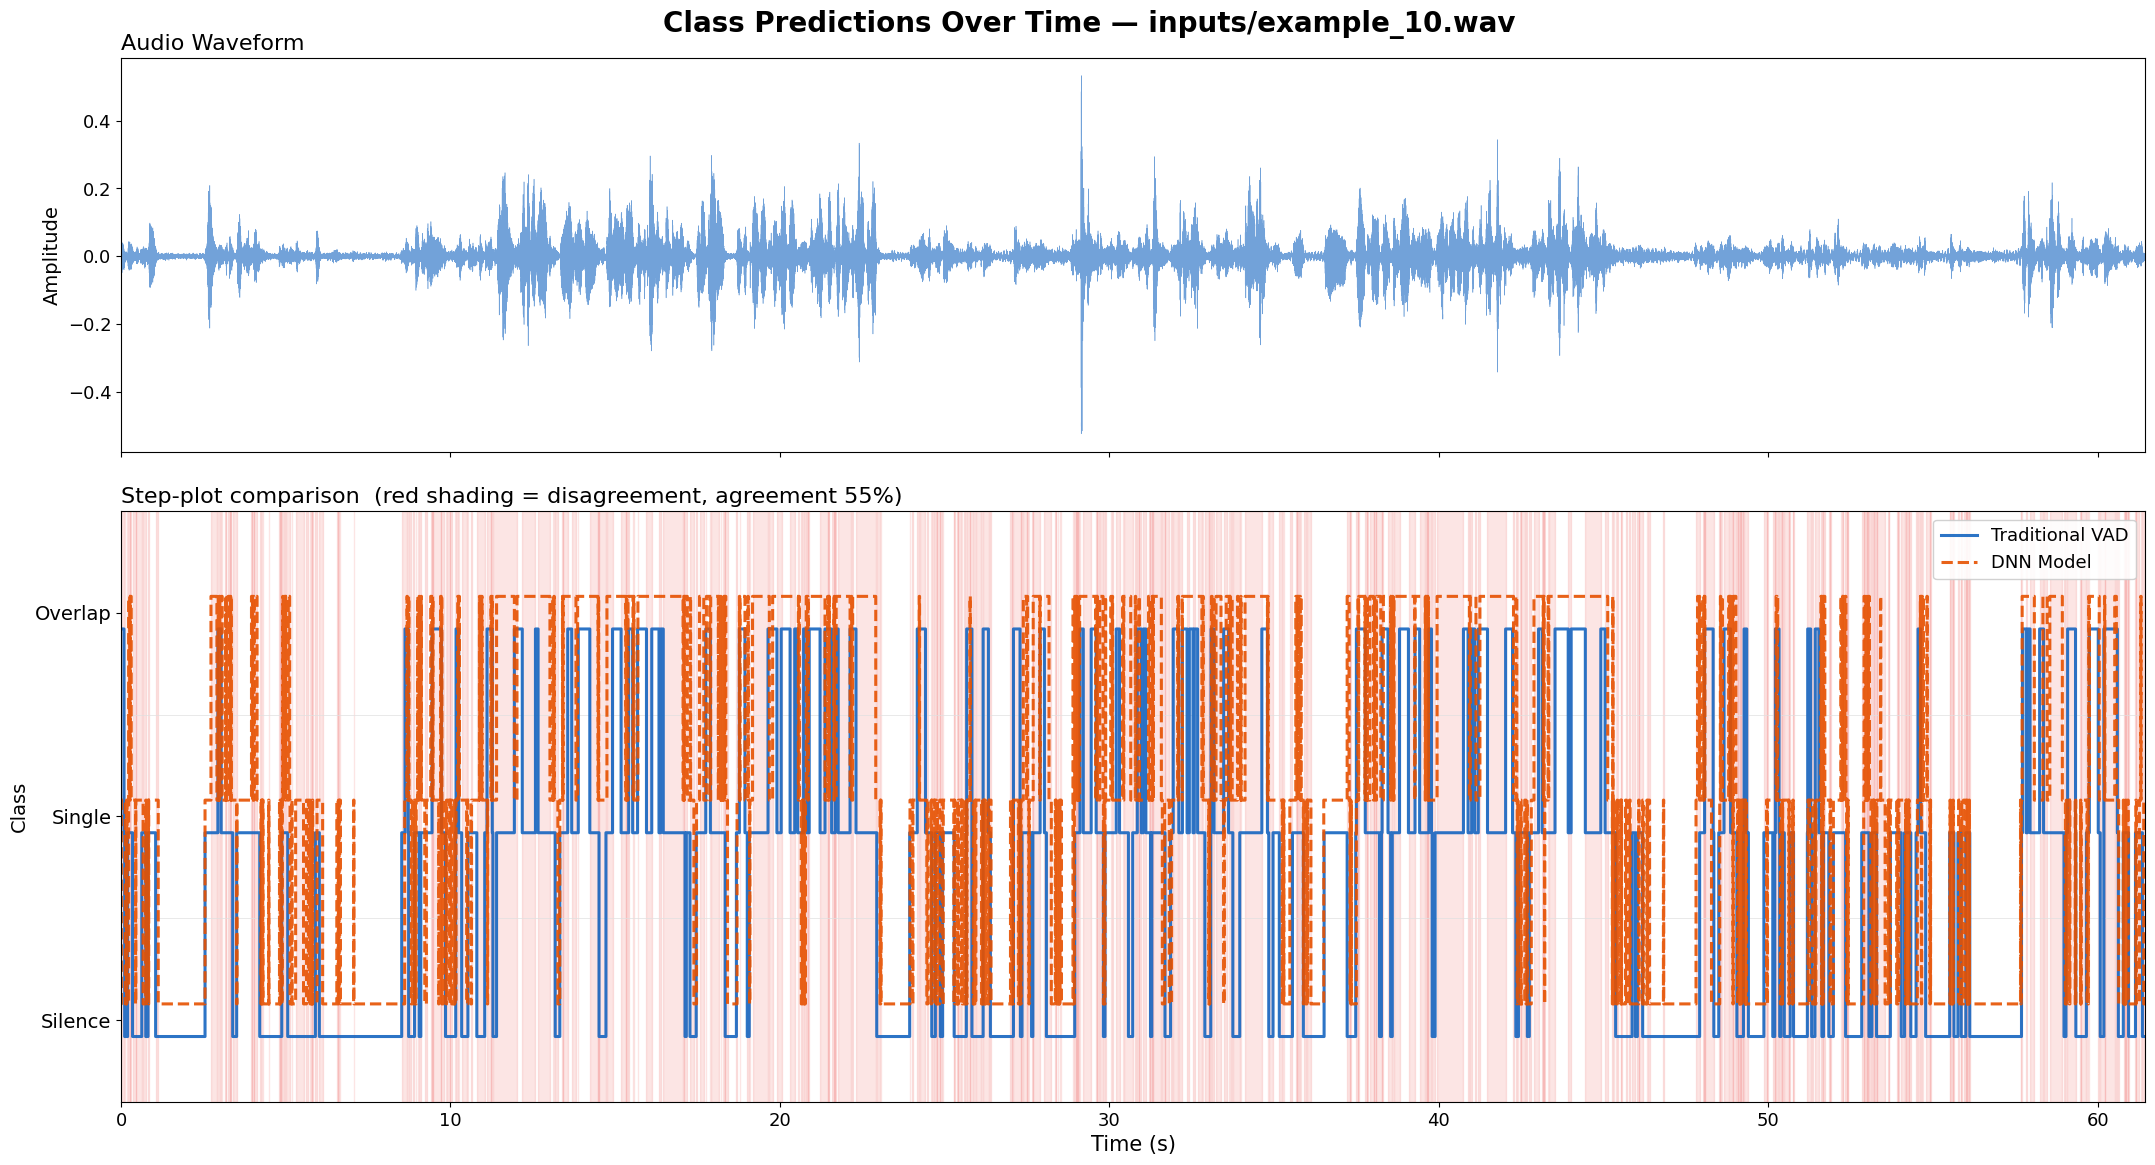

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(22, 12), sharex=True,
                         gridspec_kw={'height_ratios': [1, 1.5], 'hspace': 0.12})
fig.suptitle(f'Class Predictions Over Time — {INPUT_WAV}',
             fontsize=20, fontweight='bold', y=0.97)

# ── Panel 1: Waveform (light) ────────────────────────────────────────────
axes[0].plot(t_sig, signal, lw=0.4, color='#1565c0', alpha=0.6)
axes[0].set_ylabel('Amplitude', fontsize=14)
axes[0].set_title('Audio Waveform', fontsize=16, loc='left')
axes[0].tick_params(axis='both', labelsize=13)
axes[0].margins(x=0)

# ── Panel 2: Both models as step plots ───────────────────────────────────
# Offset DNN slightly so both lines are visible when they overlap
offset = 0.08
axes[1].step(trad_times, trad_labels.astype(float) - offset,
             where='post', lw=2.2, color='#1565c0', alpha=0.9,
             label='Traditional VAD')
axes[1].step(dnn_times, dnn_labels.astype(float) + offset,
             where='post', lw=2.2, color='#e65100', alpha=0.9,
             label='DNN Model', linestyle='--')

# Shade disagreement regions
for start, dur, lab in agree_segs:
    if lab == 0:  # disagree
        axes[1].axvspan(start, start + dur, alpha=0.15, color='#ef5350',
                        zorder=0)

axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(['Silence', 'Single', 'Overlap'], fontsize=14)
axes[1].set_ylim(-0.4, 2.5)
axes[1].set_ylabel('Class', fontsize=14)
axes[1].set_xlabel('Time (s)', fontsize=15)
axes[1].tick_params(axis='x', labelsize=13)
axes[1].margins(x=0)
axes[1].legend(loc='upper right', fontsize=13, framealpha=0.9)
axes[1].set_title(f'Step-plot comparison  (red shading = disagreement, '
                  f'agreement {agree_pct:.0f}%)',
                  fontsize=16, loc='left')
# Light grid on class boundaries
for y in [0.5, 1.5]:
    axes[1].axhline(y, color='#e0e0e0', lw=0.5, zorder=0)

fig.subplots_adjust(left=0.06, right=0.98, top=0.93, bottom=0.06)
plt.show()

# ── Per-class Duration Summary ────────────────────────────────────────────
print(f"{'Class':<20s}  {'Traditional':>14s}  {'DNN':>14s}")
print(f"{'─' * 52}")
for lab, name in [(0, 'Silence / noise'), (1, 'Single speaker'),
                   (2, 'Overlap (≥2)')]:
    t_dur = np.sum(trad_labels == lab) * hop_s
    t_pct = np.sum(trad_labels == lab) / n_trad * 100
    d_dur = np.sum(dnn_labels == lab) * dnn_hop_s
    d_pct = np.sum(dnn_labels == lab) / n_dnn * 100
    print(f"{name:<20s}  {t_dur:6.2f}s ({t_pct:5.1f}%)  "
          f"{d_dur:6.2f}s ({d_pct:5.1f}%)")

# Quick frame-level agreement (on overlapping portion, using nearest-frame)
common_n = min(n_trad, n_dnn)
agree = np.sum(trad_labels[:common_n] == dnn_labels[:common_n])
print(f"\nFrame agreement (first {common_n} frames): "
      f"{agree:,} / {common_n:,} ({agree/common_n*100:.1f}%)")